# Load the data and split it

In [19]:
from helper import get_data, plot_accuracy, plot_loss, plot_confusion_matrix, plot_samples
import matplotlib.pyplot as plt
from keras import layers, models

from helper import plot_accuracy

image_size = (64, 64)

(train_images, test_images, label_names) = get_data(image_size)

print("Number of training batches: ", len(train_images))
print("Number of testing batches: ", len(test_images))
print("Class names: ", label_names)

Using 52500 files for training.
Using 22500 files for validation.
Number of training batches:  410
Number of testing batches:  176
Class names:  ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


£# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

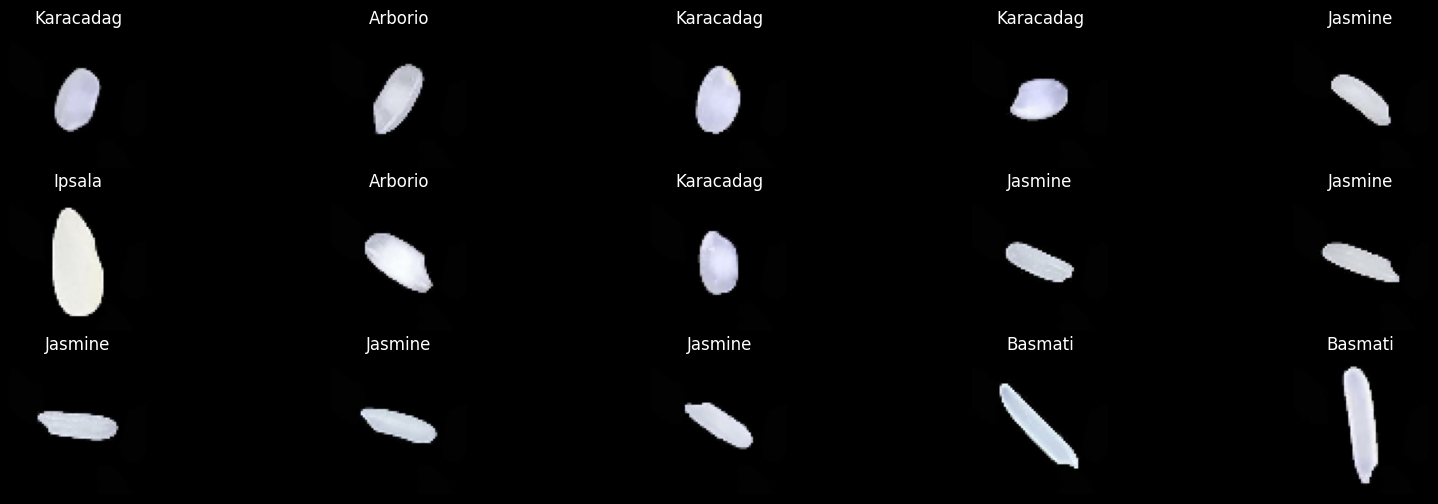

In [20]:
plot_samples(plt, train_images, label_names)

In [26]:
model = models.Sequential([
    layers.Input(shape=image_size + (3,)),
    layers.Conv2D(256, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 62, 62, 256)    │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 31, 31, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 29, 29, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,029 (1.51 MB)

 Trainable params: 397,029 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [28]:
history = model.fit(train_images, epochs=10, validation_data=test_images)

Epoch 1/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 141s 314ms/step - accuracy: 0.8849 - loss: 0.5645 - val_accuracy: 0.9491 - val_loss: 0.1416
Epoch 2/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 128s 286ms/step - accuracy: 0.9521 - loss: 0.1403 - val_accuracy: 0.9581 - val_loss: 0.1185
Epoch 3/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 128s 286ms/step - accuracy: 0.9591 - loss: 0.1252 - val_accuracy: 0.9563 - val_loss: 0.1274
Epoch 4/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 126s 280ms/step - accuracy: 0.9608 - loss: 0.1138 - val_accuracy: 0.9622 - val_loss: 0.1104
Epoch 5/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 132s 296ms/step - accuracy: 0.9636 - loss: 0.1056 - val_accuracy: 0.9618 - val_loss: 0.1237
Epoch 6/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 134s 300ms/step - accuracy: 0.9667 - loss: 0.0982 - val_accuracy: 0.9688 - val_loss: 0.1047
Epoch 7/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 129s 287ms/step - accuracy: 0.9671 - loss: 0.0997 - val_accuracy: 0.9691 - val_loss: 0.0936
Epoch 8/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 123s 272ms/step - accuracy: 0.9723 -

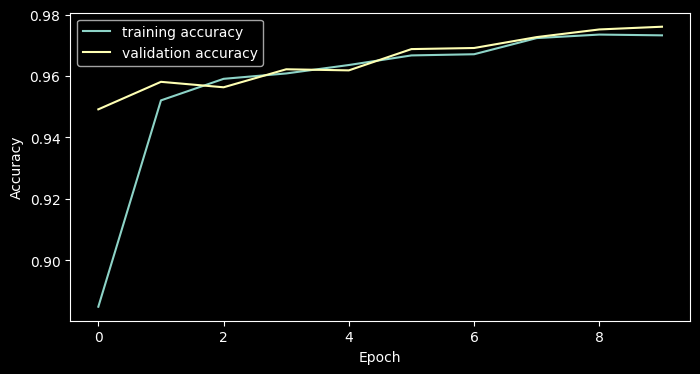

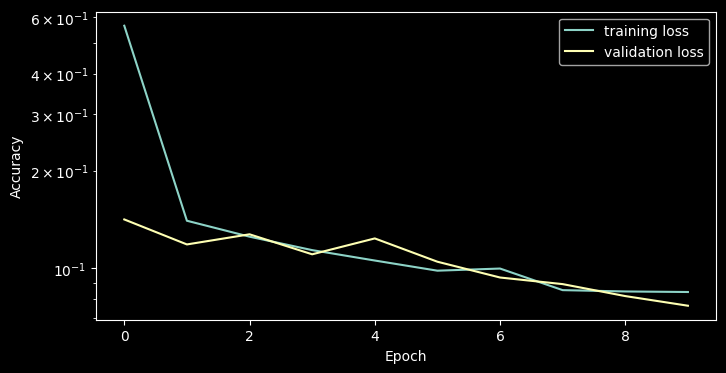

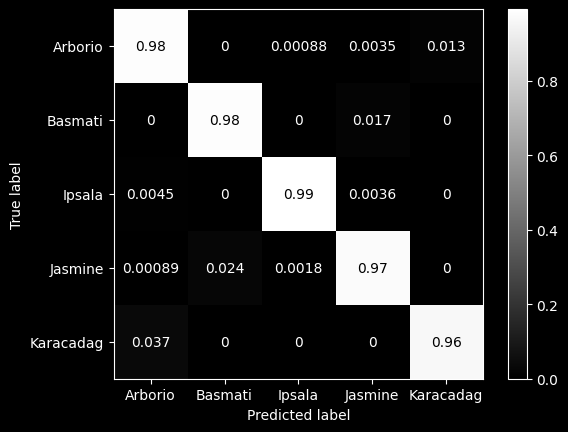

In [29]:
plot_accuracy(plt, history.history["accuracy"], history.history["val_accuracy"])
plot_loss(plt, history.history["loss"], history.history["val_loss"])
plot_confusion_matrix(model, test_images, label_names)